<div style="background-color:#1F3864; padding:25px; border-radius:8px;">
<h1 style="color:white; text-align:center; margin:0;">Fraud Detection System — Exploratory Data Analysis</h1>
<p style="color:#D9E2F3; text-align:center; margin-top:10px; font-size:15px;">
Exploring transaction patterns in the PaySim synthetic financial dataset — class imbalance, fraud by transaction type, and amount disparities — before building the fraud classification model.
</p>
</div>

In [6]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

<div style="background-color:#EDCC80; padding:15px; border-radius:8px;">
<h2 style="color:#1F3864; text-align:center; margin:0;">1. Load the Data</h2>
</div>

In [7]:
data = pd.read_csv("../data/PS_20174392719_1491204439457_log.csv")

<div style="background-color:#EDCC80; padding:15px; border-radius:8px;">
<h2 style="color:#1F3864; text-align:center; margin:0;">2. Review Data Structure</h2>
</div>

In [8]:
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [9]:
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [10]:
data.shape

(6362620, 11)

In [11]:
data.isna().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [12]:
data["isFraud"].value_counts(normalize = True)

isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64


## 1.1 Class Distribution
Fraud accounts for only **0.129%** of transactions. This has a direct consequence: **accuracy is not a valid metric for this problem.** A model that predicts "not fraud" for every single transaction would score 99.87% accuracy while catching zero actual fraud cases — the metric would reward doing nothing useful.
**Implication for evaluation:** this project uses Precision, Recall, F1, and PR-AUC instead of accuracy, since these metrics actually reflect whether fraud is being detected.


In [13]:
data[data["isFraud"]==1]["type"].value_counts()

type
CASH_OUT    4116
TRANSFER    4097
Name: count, dtype: int64

## 1.2 Fraud by Transaction Type and Amount

**Transaction type:**

In [14]:
data.groupby('isFraud')['amount'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.781970e+05,5.962370e+05,0.01,13368.395,74684.72,208364.76,92445516.64
1,8213.0,1.467967e+06,2.404253e+06,0.00,127091.330,441423.44,1517771.48,10000000.00


In [15]:
total_volume = data['amount'].sum()
fraud_volume = data[data['isFraud']==1]['amount'].sum()
print(f"Total volume: ${total_volume:,.2f}")
print(f"Fraud volume: ${fraud_volume:,.2f}")
print(f"Fraud % of total volume: {fraud_volume/total_volume*100:.2f}%")

Total volume: $1,144,392,944,759.77
Fraud volume: $12,056,415,427.84
Fraud % of total volume: 1.05%


Fraud occurs **exclusively** in `TRANSFER` and `CASH_OUT` transactions — zero fraud cases in `PAYMENT`, `CASH_IN`, or `DEBIT`. This matches the known real-world fraud pattern for mobile money: funds are moved to another account (`TRANSFER`), then withdrawn as cash (`CASH_OUT`) before detection. `type` is therefore a very strong feature, and the other three types could in principle be excluded from scoring entirely since they carry zero fraud risk in this data.

**Transaction amount:**

| | count | mean | median (50%) | max |
|---|---|---|---|---|
| Not Fraud (0) | 6,354,407 | $178,197 | $74,685 | $92,445,517 |
| Fraud (1) | 8,213 | $1,467,967 | $441,423 | $10,000,000 |

Fraudulent transactions are **~6-8x larger** than legitimate ones on average, and the gap holds at the median too — not just a few outliers skewing the mean. `amount` is likely to be a strong predictive feature alongside `type`.

*Note: fraud's max amount is suspiciously capped at exactly $10,000,000 — likely an artifact of how the PaySim simulator generated synthetic fraud cases, not a pattern expected in real-world data.*

## 1.3 Financial Impact of Fraud

| Metric | Value |
|---|---|
| Total transaction volume | $1,144,392,944,759.77 |
| Total fraud volume | $12,056,415,427.84 |
| Fraud as % of total volume | **1.05%** |
| Fraud as % of transaction count | 0.13% |

Although fraudulent transactions make up only **0.13% of all transactions by count**, they account for **1.05% of total transaction value** — roughly **8x disproportionate impact**. This confirms the earlier finding: fraud transactions are systematically larger than normal ones, so even though they're rare in number, their financial footprint is meaningfully outsized relative to their frequency.

**Business framing:** detecting even a fraction of these cases has outsized value — missing a single large fraudulent transaction costs far more than missing a typical legitimate one.

<div style="background-color:#EDCC80; padding:15px; border-radius:8px;">
<h2 style="color:#1F3864; text-align:center; margin:0;">3. Explanatory Data Analysis(EDA)</h2>
</div>

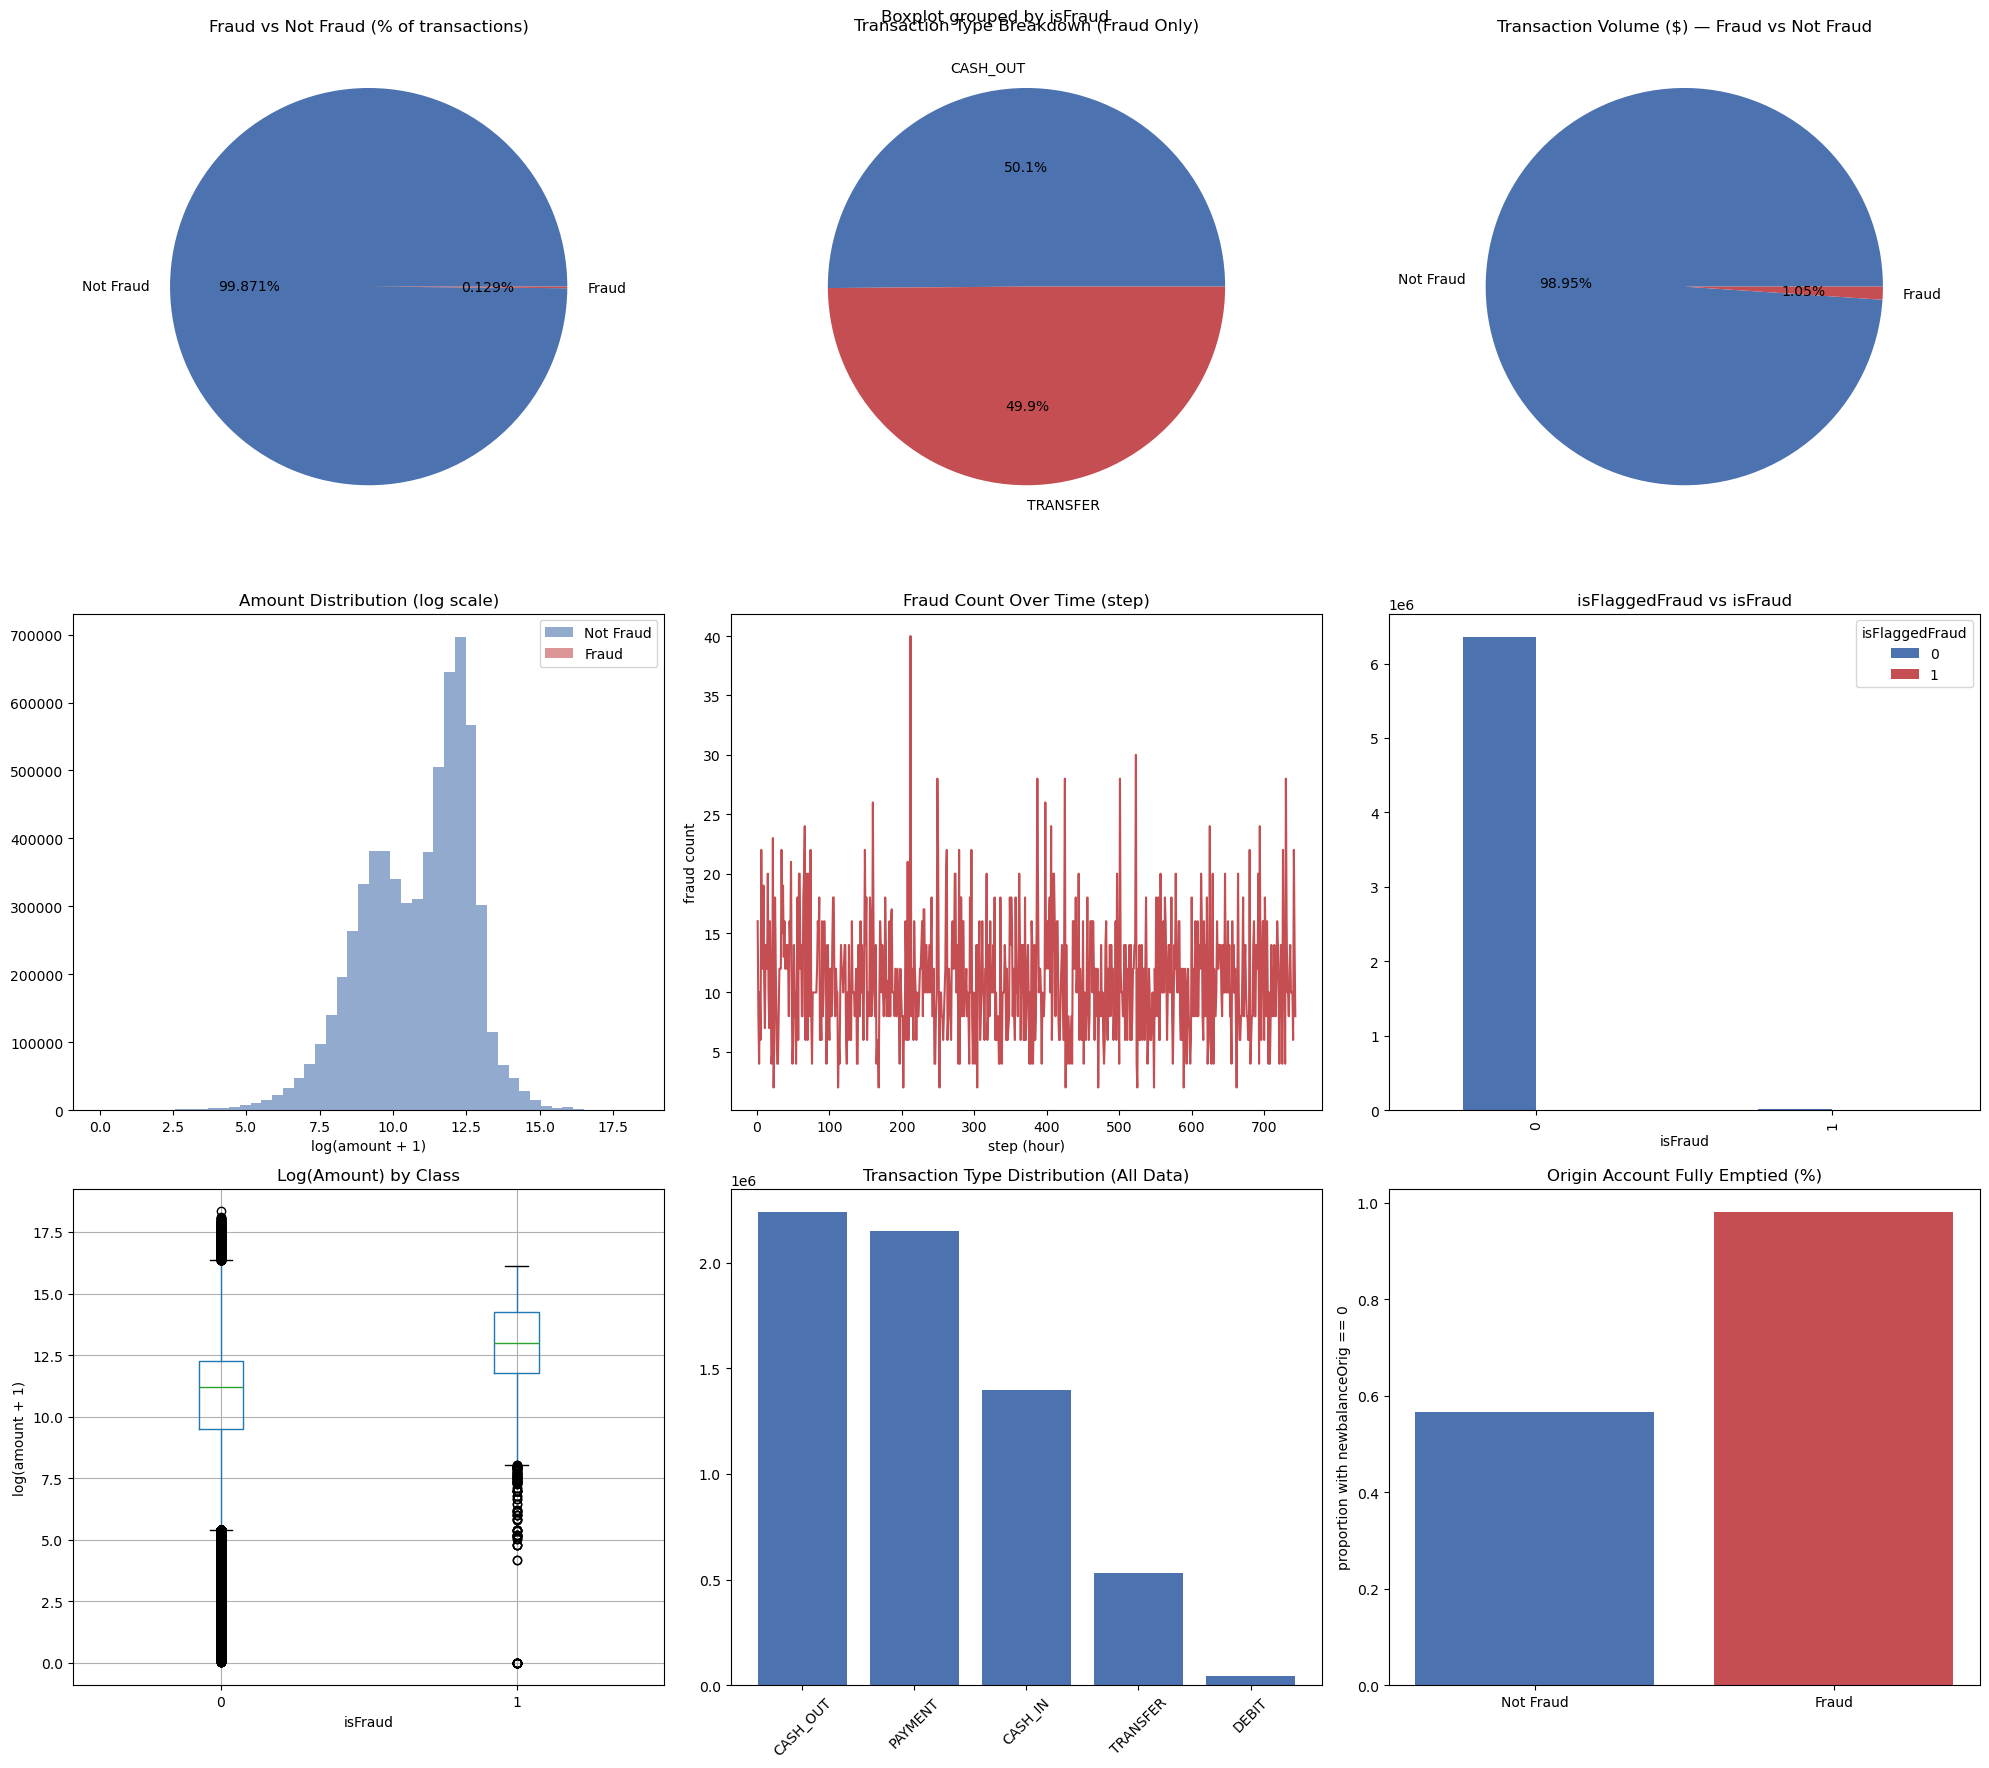

In [22]:
fig, ax = plt.subplots(3, 3, figsize=(20, 18))
ax = ax.flatten()

# --- Chart 0: Fraud vs Not Fraud ---
fraud_counts = data['isFraud'].value_counts()
ax[0].pie(fraud_counts, labels=['Not Fraud', 'Fraud'], autopct='%1.3f%%', colors=['#4C72B0', '#C44E52'])
ax[0].set_title('Fraud vs Not Fraud (% of transactions)')

# --- Chart 1: Transaction type breakdown, fraud only ---
fraud_type_counts = data[data['isFraud'] == 1]['type'].value_counts()
ax[1].pie(fraud_type_counts, labels=fraud_type_counts.index, autopct='%1.1f%%', colors=['#4C72B0', '#C44E52'])
ax[1].set_title('Transaction Type Breakdown (Fraud Only)')

# --- Chart 2: Fraud volume vs non-fraud volume ---
volume_by_class = data.groupby('isFraud')['amount'].sum()
ax[2].pie(volume_by_class, labels=['Not Fraud', 'Fraud'], autopct='%1.2f%%', colors=['#4C72B0', '#C44E52'])
ax[2].set_title('Transaction Volume ($) — Fraud vs Not Fraud')

# --- Chart 3: Amount distribution (log scale) — fraud vs not fraud ---
ax[3].hist(np.log1p(data[data['isFraud']==0]['amount']), bins=50, alpha=0.6, label='Not Fraud', color='#4C72B0')
ax[3].hist(np.log1p(data[data['isFraud']==1]['amount']), bins=50, alpha=0.6, label='Fraud', color='#C44E52')
ax[3].set_title('Amount Distribution (log scale)')
ax[3].set_xlabel('log(amount + 1)')
ax[3].legend()

# --- Chart 4: Fraud count over time (step) ---
fraud_by_step = data[data['isFraud']==1].groupby('step').size()
ax[4].plot(fraud_by_step.index, fraud_by_step.values, color='#C44E52')
ax[4].set_title('Fraud Count Over Time (step)')
ax[4].set_xlabel('step (hour)')
ax[4].set_ylabel('fraud count')

# --- Chart 5: isFlaggedFraud vs isFraud ---
flag_vs_fraud = pd.crosstab(data['isFraud'], data['isFlaggedFraud'])
flag_vs_fraud.plot(kind='bar', ax=ax[5], color=['#4C72B0', '#C44E52'])
ax[5].set_title('isFlaggedFraud vs isFraud')
ax[5].set_xlabel('isFraud')
ax[5].legend(title='isFlaggedFraud')

# --- Chart 6: Amount boxplot by class (log scale) ---
data_plot = data.copy()
data_plot['log_amount'] = np.log1p(data_plot['amount'])
data_plot.boxplot(column='log_amount', by='isFraud', ax=ax[6])
ax[6].set_title('Log(Amount) by Class')
ax[6].set_xlabel('isFraud')
ax[6].set_ylabel('log(amount + 1)')

# --- Chart 7: Overall transaction type distribution (all data) ---
type_counts = data['type'].value_counts()
ax[7].bar(type_counts.index, type_counts.values, color='#4C72B0')
ax[7].set_title('Transaction Type Distribution (All Data)')
ax[7].tick_params(axis='x', rotation=45)

# --- Chart 8: Origin account emptied out — fraud vs not fraud ---
data_plot['origin_emptied'] = data_plot['newbalanceOrig'] == 0
emptied_rate = data_plot.groupby('isFraud')['origin_emptied'].mean()
ax[8].bar(['Not Fraud', 'Fraud'], emptied_rate.values, color=['#4C72B0', '#C44E52'])
ax[8].set_title('Origin Account Fully Emptied (%)')
ax[8].set_ylabel('proportion with newbalanceOrig == 0')

plt.tight_layout()
plt.show()

## 6. Visual EDA Summary

### 6.1 Class Imbalance (Pie Charts)
Confirms the imbalance numerically found earlier: fraud is **0.129%** of transactions by count but **1.05%** of total transaction volume — fraud punches ~8x above its weight in dollar terms, even though it's nearly invisible by count.

### 6.2 Fraud by Transaction Type
Fraud splits almost evenly between `CASH_OUT` (50.1%) and `TRANSFER` (49.9%), and occurs in no other type — consistent with the fraud pattern of moving money out (`TRANSFER`) then cashing it out (`CASH_OUT`).

### 6.3 Amount Distribution & Boxplot
Fraudulent transactions skew toward higher amounts — the boxplot shows a clearly higher median `log(amount)` for fraud (~13) vs non-fraud (~11), reinforcing the earlier finding that fraud transactions are larger on average.

### 6.4 Fraud Over Time (`step`)
No strong time-of-day or trend pattern — fraud count fluctuates noisily between 0-40 per step across all 744 hours, with no obvious clustering. `step` alone is unlikely to be a strong standalone feature.

### 6.5 `isFlaggedFraud` vs `isFraud`
The simulator's own flagging rule (`isFlaggedFraud`) fires almost never — it's essentially always 0, even for actual fraud cases. This confirms `isFlaggedFraud` is **not a useful feature** (it barely catches any real fraud) and should be excluded from modeling.

### 6.6 Overall Transaction Type Distribution
Across all transactions (fraud and not), `CASH_OUT` and `PAYMENT` dominate volume by count, while `TRANSFER` — the type most associated with fraud — makes up a much smaller share. This means fraud is concentrated in a relatively rare transaction type, which should make it easier for a model to isolate.

### 6.7 Origin Account Fully Emptied
A striking signal: **~98% of fraudulent transactions fully empty the origin account** (`newbalanceOrig == 0`), compared to only ~57% of legitimate ones. This is the clearest behavioral fraud pattern found so far — though since it uses `newbalanceOrig`, it falls under the leakage columns excluded from modeling (see Finding #5).